![image.png](https://i.imgur.com/a3uAqnb.png)

## 1️⃣ Dataset

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
import torch.optim as optim
# Define transformations (convert to tensor)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load CIFAR-100 dataset
train_dataset = STL10(root="./data", split="train", transform=transform, download=True)
test_dataset = STL10(root="./data", split='test', transform=transform, download=True)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

100%|██████████| 2.64G/2.64G [00:44<00:00, 58.7MB/s]


#### Check dataset size


In [2]:
print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")

Training samples: 5000, Testing samples: 8000


In [3]:
train_dataset.classes

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

#### Display some images

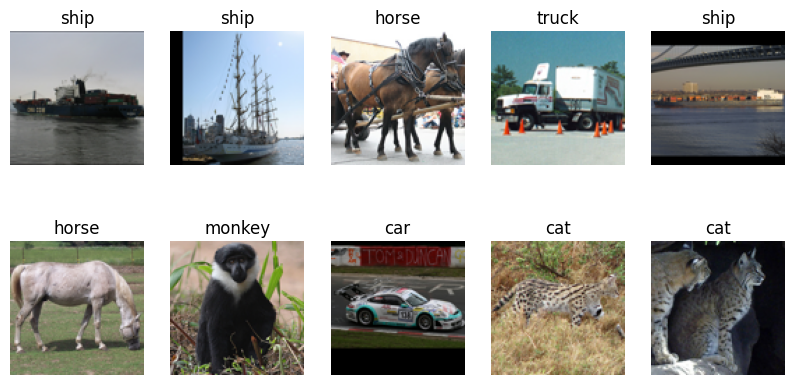

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# CIFAR-10 class names
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
# Show images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = np.transpose(img.numpy(), (1, 2, 0))  # Convert (C, H, W) to (H, W, C)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.show()

### Check the dataset shape

In [5]:
print("Shape of one image tensor:", images[0].shape)

Shape of one image tensor: torch.Size([3, 96, 96])


## 2️⃣ Model Class

In [6]:
import torch
import torch.nn as nn

# Define the Feedforward Neural Network (MLP)
class NNModel(nn.Module):
    def __init__(self):
        super(NNModel, self).__init__()

        # Fully Connected Layers
        self.fc1 = nn.Linear(3 * 96 * 96, 512)  # Input: 3072 features
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)  # 10 classes for CIFAR-10

        # Activation function
        self.relu = nn.ReLU()
        # Optional dropout to reduce overfitting
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Flatten the image: (batch_size, 3, 32, 32) -> (batch_size, 3072)
        x = x.view(x.size(0), -1)

        # Fully Connected Layers with ReLU + Dropout
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # Logits output (no activation, since CrossEntropyLoss applies Softmax)

        return x

## 3️⃣ Training loop

In [7]:
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        predictions = outputs.argmax(dim=1)  # No softmax needed
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

##  4️⃣ Validation Loop

In [8]:
# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

## 5️⃣ Running Training

In [11]:
# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NNModel().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [12]:
# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

Validating: 100%|██████████| 250/250 [00:04<00:00, 58.23it/s]


Epoch 1/10: Train Loss=2.2211, Train Accuracy=15.66%, Val Loss=1.9711, Val Accuracy=21.01%


Validating: 100%|██████████| 250/250 [00:03<00:00, 75.51it/s]


Epoch 2/10: Train Loss=2.0079, Train Accuracy=21.44%, Val Loss=1.9295, Val Accuracy=24.77%


Validating: 100%|██████████| 250/250 [00:04<00:00, 58.35it/s]


...

Epoch 8/10: Train Loss=1.8639, Train Accuracy=29.38%, Val Loss=1.8342, Val Accuracy=31.12%


Validating: 100%|██████████| 250/250 [00:03<00:00, 78.40it/s]


Epoch 9/10: Train Loss=1.8485, Train Accuracy=28.68%, Val Loss=1.8014, Val Accuracy=30.49%


Validating: 100%|██████████| 250/250 [00:03<00:00, 76.27it/s]

Epoch 10/10: Train Loss=1.8461, Train Accuracy=28.70%, Val Loss=1.7804, Val Accuracy=31.64%


## 6️⃣   Plot loss and accuracy for training and validation

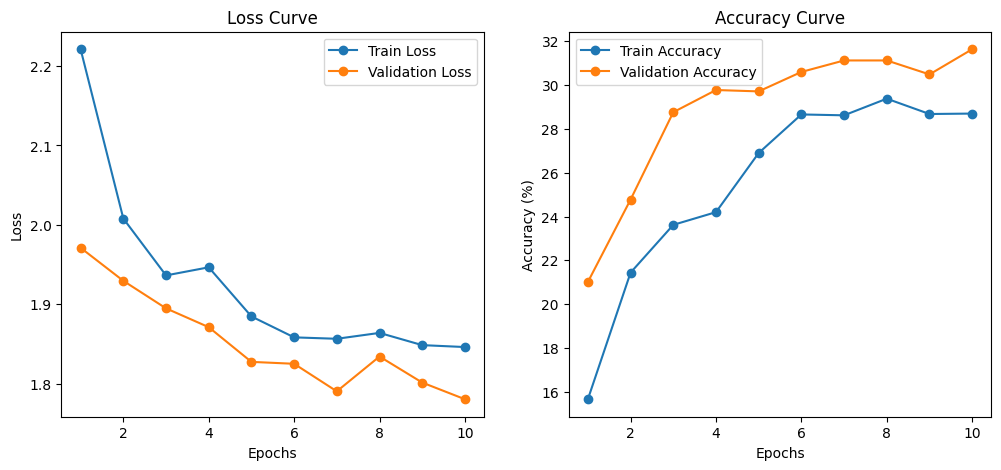

In [13]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


## 7️⃣ Display sample of predictions  

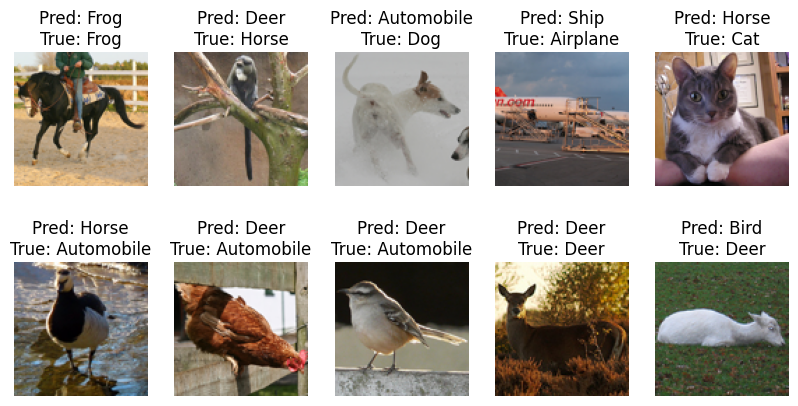

In [14]:
import numpy as np

# Function to display images with predicted labels
def show_predictions(model, dataloader, device, num_images=10):
    model.eval()  # Set to evaluation mode
    images, labels = next(iter(dataloader))  # Get a batch
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():  # Disable gradient computation
        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # Get predicted class

    # CIFAR-10 class names
    classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

    # Plot images with predictions
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat[:num_images]):
        img = images[i]
        img = np.transpose(img.cpu().numpy(), (1, 2, 0))  # Convert to (H, W, C)

        ax.imshow(img)
        ax.set_title(f"Pred: {classes[predictions[i].item()]}\nTrue: {classes[labels[i].item()]}")
        ax.axis("off")

    plt.show()

# Show predictions
show_predictions(model, test_loader, device)
